<a href="https://colab.research.google.com/github/letiBri/MaskArchitectureAnomaly_CourseProject/blob/main/eomt/STEP5_semanticPlotCocoFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

In [ ]:
!git clone https://github.com/letiBri/MaskArchitectureAnomaly_CourseProject.git

%cd MaskArchitectureAnomaly_CourseProject/eomt

Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 493, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 493 (delta 41), reused 24 (delta 24), pack-reused 443 (from 3)
Receiving objects: 100% (493/493), 32.59 MiB | 10.02 MiB/s, done.
Resolving deltas: 100% (213/213), done.
/content/MaskArchitectureAnomaly_CourseProject/eomt/MaskArchitectureAnomaly_CourseProject/eomt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject')
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject/eomt')

In [ ]:
!python3 -m pip install -r requirements.txt

## Setup

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0
IGNORE_INDEX = 255
img_idx = 75
data_path = "/content/drive/MyDrive/CourseProjectAnomaly"

with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "r") as f:
    config_cs = yaml.safe_load(f)

with open("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml", "r") as f:
    config_coco = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
data_module_name, class_name = config_cs["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_cs["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)
data.setup()

## Load model

In [ ]:
current_config = config_coco
state_dict_path = "/content/drive/MyDrive/CourseProjectAnomaly/eomt_coco_finetuned.bin"
target_img_size = (640, 640)
num_classes_to_load = 19


warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = current_config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=target_img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = current_config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=num_classes_to_load,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = current_config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in current_config["model"]["init_args"].items() if k != "network"}

if "stuff_classes" in current_config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = current_config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [ ]:
target_img_size = (640, 640) # img size Coco

model_kwargs_final = {k: v for k, v in model_kwargs.items()}

if "num_classes" in model_kwargs_final:
  del model_kwargs_final["num_classes"]

name = current_config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")
is_dinov3 = "dinov3" in name if name else False

if is_dinov3:
    model_kwargs["ckpt_path"] = state_dict_path
    model_kwargs["delta_weights"] = True

model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs_final,
    )
    .eval()
    .to(device)
)

if not is_dinov3:
    state_dict = torch.load(
        state_dict_path, map_location=f"cuda:{device}", weights_only=True
    )
    model.load_state_dict(state_dict, strict=False)


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
def infer_semantic(img, target):
    model.eval()

    # Force the model to use the right window dimension (640 for COCO, 1024 for Cityscapes)
    model.window_size = target_img_size[0]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], target_img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()

    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    img_np = img.permute(1, 2, 0).cpu().numpy()
    if img_np.max() > 1.0 or img_np.min() < 0:
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

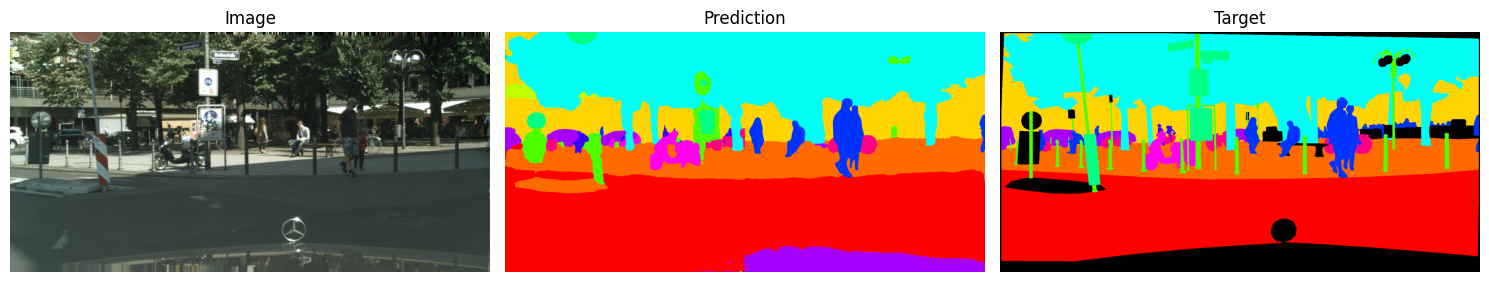

In [ ]:
img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)